# Transducer Belief Decomposition — three observation regimes

**Goal (aim.md §10.4 + Coarse-Graining Roots §556):** an autonomous **input HMM** `T^(y)`
(states R) drives a **transducer** `U^(x|y)` (states S). The joint hidden state is `(R, S)`.
We test what a transformer's residual stream linearly encodes **depending on which tokens it is
trained on** — this is the crux from the mentor meeting.

**The operators (built analytically):**
- Fully observable joint (train on both `y` and `x`): `V^(y,x) = kron(T^(y), U^(x|y))`.
  Belief states are **tensor products** → input & transducer beliefs are *separable*, low-dim.
- Coarse-grain the intermediate `y` (train on `x` only): `W^(x) = Σ_y kron(T^(y), U^(x|y))`.
  The sum over hidden `y` **entangles** R and S → beliefs fill the full `(|R||S|-1)`-simplex
  (the "cascade" tetrahedron in the explorer). *This is what composite_mess3 actually was.*
- Coarse-grain the output `x` (train on `y` only): reduces to the **input HMM's MSP**.

**Set `OBSERVE` in the config** to pick the regime the transformer is trained & probed on:
`'joint'` | `'output_only'` (coarse-grain intermediate) | `'input_only'` (coarse-grain output).
In every regime the belief lives on the same `(R,S)` space, so we always probe three targets —
**joint belief, input marginal, transducer marginal** — and report a **separability diagnostic**,
an **untrained baseline per target**, and a **predictive metric** (`d_mu` KL + entropy-rate gap).

**Key question (mentor):** *how much information does the transducer erase?* = how much of the
separable structure survives when we coarse-grain the intermediate token. Compare a `joint` run
vs an `output_only` run on the same process.

**Runtime:** torch + numpy only (no JAX ⇒ no GPU-memory contention). ~30–60 min / 1M steps on A100.
Cell 6 draws all three analytical manifolds (matching `explorer.html`) regardless of `OBSERVE`.

In [1]:
!pip install -q transformer-lens 2>&1 | tail -1
import sys, torch
print(f'Python {sys.version.split()[0]}  |  PyTorch {torch.__version__}  |  CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 6.5 MB/s eta 0:00:00
Python 3.12.13  |  PyTorch 2.11.0+cu128  |  CUDA: True
GPU: Tesla T4


In [2]:
import warnings, json, os, zipfile, gc
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm   # plain text bar: renders reliably in the Colab/Cursor cell output
from transformer_lens import HookedTransformer, HookedTransformerConfig

warnings.filterwarnings('ignore')
if torch.cuda.is_available():
    torch.set_float32_matmul_precision('high')   # enable TF32 on A100

# =====================================================================
#  CONFIG
# =====================================================================
# OBSERVE = which tokens the transformer is trained & probed on (the mentor's key axis):
#   'joint'        -> train on composite (y,x); belief operator V (separable / tensor product).
#   'output_only'  -> train on x only (coarse-grain intermediate y); operator W (ENTANGLED).
#   'input_only'   -> train on y only (coarse-grain output x); reduces to the input HMM's MSP.
# Recommended first run: 'joint' (clean separable baseline). Then 'output_only' for the
# "how much does the transducer erase" question, and compare the two saved runs.
OBSERVE = 'output_only'

# INPUT_MODE = autonomous input HMM driving the transducer:
#   'iid' (1 state, trivial input belief) | 'sns' | 'fractal2' | 'mess3'
INPUT_MODE = 'fractal2'

# TRANSDUCER_MODE = output transducer U^(x|y):
#   'sns' (nonunifilar, countable) | 'fractal2' | 'mess3'
TRANSDUCER_MODE = 'fractal2'

# ---- Input HMM parameters ----
IID_P1 = 0.5
SNS_IN_P = 0.5
FRACTAL2_IN_BPQ = (0.85, 0.5, 0.5)        # (b, p, q); b~0.85 keeps the process predictable (b=0.5 is degenerate)
MESS3_IN_X, MESS3_IN_A = 0.05, 0.85

# ---- Transducer parameters (one parameter set PER input symbol y) ----
SNS_TR_P0, SNS_TR_P1 = 0.35, 0.80          # SNS self-loop prob for input 0 / input 1
FRACTAL2_TR_PARAMS = [(0.85, 0.15, 0.15), (0.85, 0.85, 0.85)]   # (b,p,q) per input symbol; b~0.85 = predictable
MESS3_TR_PARAMS = [(0.05, 0.85), (0.05, 0.65)]               # (x,a) per input symbol

# ---- Transformer architecture (Shai et al. Appendix A.6, extended context) ----
N_CTX = 50
D_MODEL = 64
D_HEAD = 8
N_HEADS = 1
N_LAYERS = 4
D_MLP = 256

# ---- Training ----
BATCH_SIZE = 64
LEARNING_RATE = 0.01
SEQUENCE_LEN = N_CTX + 1
NUM_STEPS = 1_000_000
SEED = 42
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# ---- Analysis ----
ANALYSIS_SEQS = 50_000

# ---- Free-tier Colab (T4) safety: caps training steps + analysis size to avoid ~12GB OOM and
#      the ~90-min idle disconnect. Set to False on Colab Pro / A100 / L4 for the full run. ----
COLAB_FREE_T4 = True
if COLAB_FREE_T4:
    NUM_STEPS = 100_000       # ~40 min on a free T4; arc + probe R2 already clear, saves GPU quota
    ANALYSIS_SEQS = 10_000    # 500k data points; keeps the float64 OLS well under the free-T4 ~12GB RAM

# ---- Checkpoint naming + optional Google Drive persistence ----
CKPT_NAME = f'transducer_ckpt_{INPUT_MODE}_{TRANSDUCER_MODE}_{OBSERVE}'  # unique per run (no overwrite)
SAVE_TO_DRIVE = True                            # also copy the zip to Drive (survives session reset)
DRIVE_DIR = '/content/drive/MyDrive/transducer_runs'

FIG_DIR = f'{CKPT_NAME}/figures'
os.makedirs(FIG_DIR, exist_ok=True)
print(f'INPUT_MODE={INPUT_MODE}  TRANSDUCER_MODE={TRANSDUCER_MODE}  OBSERVE={OBSERVE}  Device={DEVICE}')
print(f'COLAB_FREE_T4={COLAB_FREE_T4}  ->  NUM_STEPS={NUM_STEPS:,}  ANALYSIS_SEQS={ANALYSIS_SEQS:,}')
print(f'checkpoint: {CKPT_NAME}.zip   SAVE_TO_DRIVE={SAVE_TO_DRIVE} -> {DRIVE_DIR}')

INPUT_MODE=fractal2  TRANSDUCER_MODE=fractal2  OBSERVE=output_only  Device=cuda
COLAB_FREE_T4=True  ->  NUM_STEPS=100,000  ANALYSIS_SEQS=10,000
checkpoint: transducer_ckpt_fractal2_fractal2_output_only.zip   SAVE_TO_DRIVE=True -> /content/drive/MyDrive/transducer_runs


## 1. Build the joint feed-forward transducer process

Kernels are ported verbatim from `explorer.html`. The joint kernel for composite token
`(y, x)` is `Kron(T_input[y], T_transducer[y][x])` on the joint state `(R, S)`, with composite
token index `k = y * n_x + x`. We verify row-stochasticity, compute the stationary distribution,
and compute the **entropy rate** of the joint token process directly (this is the theoretical
floor for the transformer's cross-entropy loss).

In [3]:
# ---- Kernel builders (ported from explorer.html) ----
def kernel_iid_source(p):
    """IID binary source, single hidden state. T0=[[1-p]], T1=[[p]]  (P(y=1)=p)."""
    return np.array([[[1 - p]], [[p]]], dtype=np.float64)

def kernel_sns_source(p):
    """Simple Nonunifilar Source: 2 states, 2 outputs. Emitting 1 is the synchronizing symbol."""
    T0 = np.array([[p, 1 - p], [0.0, p]])
    T1 = np.array([[0.0, 0.0], [1 - p, 0.0]])
    return np.stack([T0, T1])

def kernel_mess3_source(x, a):
    """Mess3: 3 states, 3 outputs."""
    b, y = (1 - a) / 2, 1 - 2 * x
    ay, bx, by, ax = a * y, b * x, b * y, a * x
    return np.array([
        [[ay, bx, bx], [ax, by, bx], [ax, bx, by]],
        [[by, ax, bx], [bx, ay, bx], [bx, ax, by]],
        [[by, bx, ax], [bx, by, ax], [bx, bx, ay]],
    ], dtype=np.float64)

def kernel_fractal2_source(b, p, q):
    """Fractal-2-state: 2 states, 2 outputs (ported from explorer.html)."""
    T0 = np.array([[b, 0.0], [(1 - b) * q, (1 - b) * (1 - q)]])
    T1 = np.array([[(1 - b) * (1 - p), (1 - b) * p], [0.0, b]])
    return np.stack([T0, T1])

def build_input_kernels():
    if INPUT_MODE == 'iid':   return kernel_iid_source(IID_P1)
    if INPUT_MODE == 'sns':   return kernel_sns_source(SNS_IN_P)
    if INPUT_MODE == 'fractal2': return kernel_fractal2_source(*FRACTAL2_IN_BPQ)
    if INPUT_MODE == 'mess3': return kernel_mess3_source(MESS3_IN_X, MESS3_IN_A)
    raise ValueError(INPUT_MODE)

def build_transducer_kernels(n_y):
    """Returns (n_y, n_x, n_S, n_S): one transducer parameter set per input symbol y."""
    per_input = []
    for yi in range(n_y):
        if TRANSDUCER_MODE == 'sns':
            per_input.append(kernel_sns_source(SNS_TR_P0 if yi % 2 == 0 else SNS_TR_P1))
        elif TRANSDUCER_MODE == 'fractal2':
            per_input.append(kernel_fractal2_source(*FRACTAL2_TR_PARAMS[yi % len(FRACTAL2_TR_PARAMS)]))
        elif TRANSDUCER_MODE == 'mess3':
            per_input.append(kernel_mess3_source(*MESS3_TR_PARAMS[yi % len(MESS3_TR_PARAMS)]))
        else:
            raise ValueError(TRANSDUCER_MODE)
    return np.stack(per_input)

def driven_transducer(input_kernels, transducer_kernels):
    """Fully-observable joint kernel V (n_y*n_x, n_R*n_S, n_R*n_S). Token k = y*n_x + x."""
    n_y = input_kernels.shape[0]
    n_x = transducer_kernels.shape[1]
    return np.stack([np.kron(input_kernels[y], transducer_kernels[y, x])
                     for y in range(n_y) for x in range(n_x)])

def coarse_grained_intermediate(V, n_y, n_x):
    """W^(x) = Σ_y V^(y,x): operator for an observer that sees only the output x (y hidden)."""
    ns = V.shape[1]
    W = np.zeros((n_x, ns, ns))
    for y in range(n_y):
        for x in range(n_x):
            W[x] += V[y * n_x + x]
    return W

def coarse_grained_output(V, n_y, n_x):
    """Σ_x V^(y,x): operator for an observer that sees only the intermediate y (x hidden)."""
    ns = V.shape[1]
    Vin = np.zeros((n_y, ns, ns))
    for y in range(n_y):
        for x in range(n_x):
            Vin[y] += V[y * n_x + x]
    return Vin

input_kernels = build_input_kernels()
n_y, n_R = input_kernels.shape[0], input_kernels.shape[1]
transducer_kernels = build_transducer_kernels(n_y)
n_x, n_S = transducer_kernels.shape[1], transducer_kernels.shape[2]
n_joint = n_R * n_S

# ---- The three regime operators (all act on the SAME joint (R,S) state space) ----
V_joint = driven_transducer(input_kernels, transducer_kernels)   # observe (y,x)
W_cg    = coarse_grained_intermediate(V_joint, n_y, n_x)          # observe x only (entangling)
V_input = coarse_grained_output(V_joint, n_y, n_x)                # observe y only (input HMM)

OPERATORS = {'joint': V_joint, 'output_only': W_cg, 'input_only': V_input}
VOCABS    = {'joint': n_y * n_x, 'output_only': n_x, 'input_only': n_y}
tmats = OPERATORS[OBSERVE]          # <-- active operator used by sampling / beliefs / training
VOCAB_SIZE = VOCABS[OBSERVE]

# ---- Verify + stationary (identical across regimes: same underlying joint chain) ----
for name, op in OPERATORS.items():
    assert np.allclose(op.sum(0).sum(1), 1.0, atol=1e-9), (name, op.sum(0).sum(1))
    assert np.all(op >= -1e-12)
T_net = V_joint.sum(axis=0)
evals, evecs = np.linalg.eig(T_net.T)
stationary = evecs[:, np.argmin(np.abs(evals - 1))].real
stationary = stationary / stationary.sum()

def joint_to_marginals(eta):
    """eta over joint (R,S) -> (input marginal over R, transducer marginal over S)."""
    m = eta.reshape(-1, n_R, n_S)
    return m.sum(axis=2), m.sum(axis=1)

print(f'OBSERVE={OBSERVE}  |  n_y={n_y} n_x={n_x}  |  n_R={n_R} n_S={n_S} (joint states={n_joint})')
print(f'active operator: {OBSERVE} -> vocab={VOCAB_SIZE}, {tmats.shape[0]} symbol-labeled matrices')
print(f'stationary (joint): {stationary.round(4)}')

# ---- Entropy rate of the ACTIVE observed process (Blackwell estimate; the loss floor) ----
def entropy_rate(op, vocab, n_steps=200_000, burn=2000, seed=0):
    rng = np.random.default_rng(seed)
    eta = stationary.copy(); h = 0.0; cnt = 0
    for t in range(n_steps):
        px = np.einsum('i,kij->k', eta, op); px = np.maximum(px, 0); px = px / px.sum()
        if t >= burn:
            h += -np.sum(px * np.log(px + 1e-300)); cnt += 1
        k = rng.choice(vocab, p=px); eta = eta @ op[k]; eta = eta / eta.sum()
    return h / cnt

ENTROPY_RATE = entropy_rate(tmats, VOCAB_SIZE)
print(f'\nEntropy rate of the {OBSERVE} process (loss floor): {ENTROPY_RATE:.4f} nats  '
      f'|  log(vocab)={np.log(VOCAB_SIZE):.4f}')
if ENTROPY_RATE > np.log(VOCAB_SIZE) - 0.05:
    print('  ** WARNING: entropy ~ log(vocab) -> the process is (near) unpredictable, so the transformer\n'
          '     will NOT learn belief geometry (probe R2 ~ untrained). Change parameters before training\n'
          '     (e.g. move fractal2 b away from 0.5, or use a more structured process). **')

OBSERVE=output_only  |  n_y=2 n_x=2  |  n_R=2 n_S=2 (joint states=4)
active operator: output_only -> vocab=2, 2 symbol-labeled matrices
stationary (joint): [0.25 0.25 0.25 0.25]

Entropy rate of the output_only process (loss floor): 0.4706 nats  |  log(vocab)=0.6931


## 2. Analytical belief manifolds — the three regimes (matches `explorer.html`)

We enumerate the MSP of each regime operator and plot the belief manifold on the
`(input-marginal, transducer-marginal)` plane, exactly like the explorer panels:

- **Fully observable (V):** beliefs factor as a tensor product → a clean **product** manifold
  (separability fraction ≈ 1).
- **Coarse-grain intermediate (W):** summing over the hidden `y` **entangles** R and S → the
  manifold fills a 2-D region (the cascade tetrahedron), separability fraction < 1.
- **Coarse-grain output (V_input):** collapses to the **input HMM's MSP** (a line/point in the
  input marginal; transducer marginal frozen at stationary).

This is the analytical prediction the mentor asked us to fit the trained model against — it is
shown for all three regimes regardless of the active `OBSERVE`.

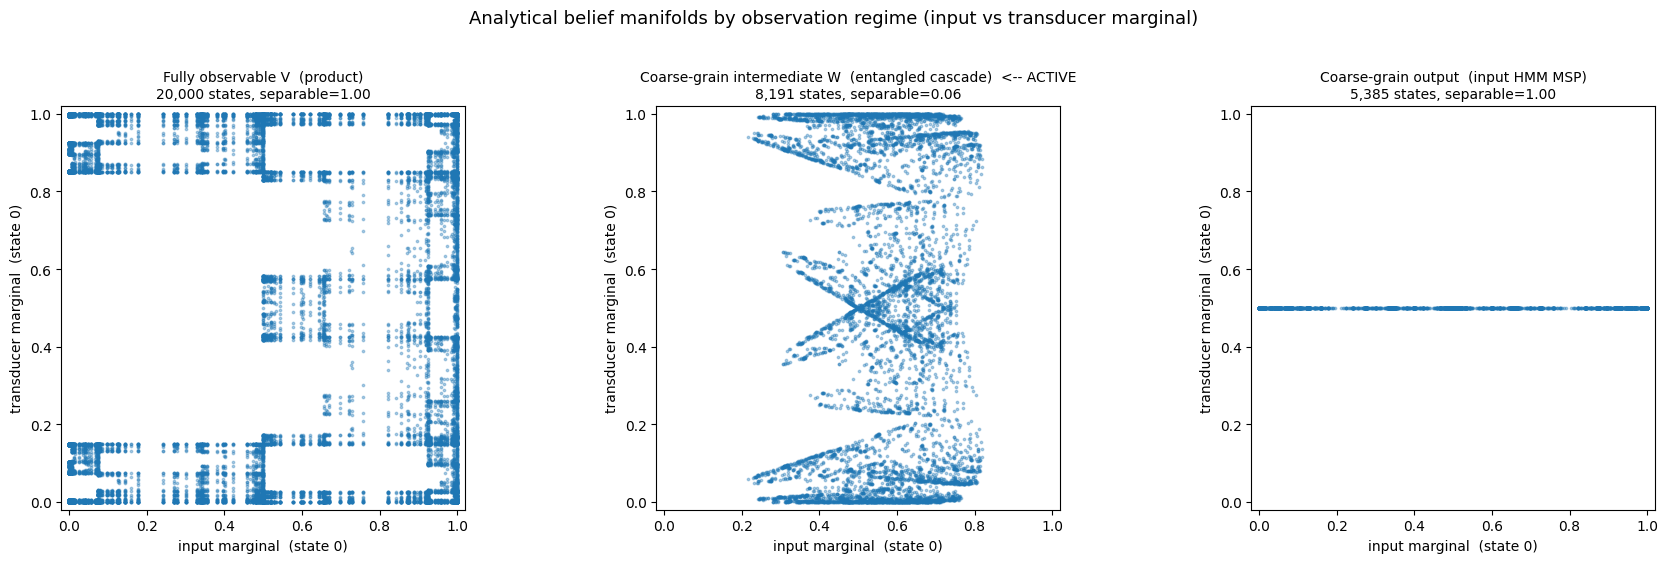

separability fraction (rank-1 beliefs): {'joint': 1.0, 'output_only': 0.059, 'input_only': 1.0}
active regime OBSERVE=output_only: 8,191 belief states, separable=0.059


In [4]:
# ---- MSP enumeration + simplex embedding ----
def build_msp_beliefs(T, init_state, max_depth, max_nodes=20000):
    """BFS over reachable belief states (dedup via rounding). Capped at max_nodes so that
    UNCOUNTABLE MSPs (Fractal2 / Mess3) don't blow up combinatorially at deep BFS."""
    beliefs = [init_state.copy()]
    seen = {tuple(init_state.round(6))}
    queue = [(init_state.copy(), 0)]
    while queue and len(beliefs) < max_nodes:
        state, depth = queue.pop(0)
        if depth >= max_depth:
            continue
        for k in range(T.shape[0]):
            raw = state @ T[k]
            norm = raw.sum()
            if norm > 1e-12:
                child = raw / norm
                key = tuple(child.round(6))
                if key not in seen:
                    seen.add(key)
                    beliefs.append(child)
                    queue.append((child, depth + 1))
                    if len(beliefs) >= max_nodes:
                        break
    return np.array(beliefs)

def embed_simplex(P):
    """Embed rows of probability vectors P (shape (N, n)) into 2D for plotting."""
    n = P.shape[1]
    if n == 1:
        return np.column_stack([np.zeros(len(P)), np.zeros(len(P))])
    if n == 2:
        return np.column_stack([P[:, 0], np.zeros(len(P))])      # 1-simplex on a line
    if n == 3:
        corners = np.array([[0.0, 0.0], [1.0, 0.0], [0.5, np.sqrt(3) / 2]])
        return P @ corners                                        # barycentric triangle
    Pc = P - P.mean(0)
    _, _, Vt = np.linalg.svd(Pc, full_matrices=False)
    return Pc @ Vt[:2].T

def frac_separable(P, tol=1e-4):
    """Fraction of joint beliefs that factor as a tensor product (reshape n_R x n_S is rank-1)."""
    if n_R == 1 or n_S == 1:
        return 1.0
    sep = 0
    for eta in P:
        s = np.linalg.svd(eta.reshape(n_R, n_S), compute_uv=False)
        if s[1] <= tol * s[0]:
            sep += 1
    return sep / len(P)

MSP_DEPTH = 12 if n_joint <= 4 else 9
msp = {name: build_msp_beliefs(op, stationary, MSP_DEPTH) for name, op in OPERATORS.items()}

# expose the active-regime MSP + marginals (used later by the viz cell)
msp_joint = msp[OBSERVE]
msp_input, msp_trans = joint_to_marginals(msp_joint)

titles = {
    'joint': 'Fully observable V  (product)',
    'output_only': 'Coarse-grain intermediate W  (entangled cascade)',
    'input_only': 'Coarse-grain output  (input HMM MSP)',
}
fig, axes = plt.subplots(1, 3, figsize=(18, 5.4))
for ax, name in zip(axes, ['joint', 'output_only', 'input_only']):
    M = msp[name]
    inm, trm = joint_to_marginals(M)
    sep = frac_separable(M)
    ax.scatter(inm[:, 0], trm[:, 0], s=3, alpha=0.35, rasterized=True)
    ax.set_xlabel('input marginal  (state 0)'); ax.set_ylabel('transducer marginal  (state 0)')
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02); ax.set_aspect('equal')
    active = '  <-- ACTIVE' if name == OBSERVE else ''
    ax.set_title(f'{titles[name]}{active}\n{len(M):,} states, separable={sep:.2f}', fontsize=10)
plt.suptitle('Analytical belief manifolds by observation regime '
             '(input vs transducer marginal)', y=1.03, fontsize=13)
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/fig_belief_manifolds.png', dpi=150, bbox_inches='tight'); plt.show()

SEPARABILITY = {name: float(frac_separable(msp[name])) for name in OPERATORS}
print('separability fraction (rank-1 beliefs):',
      {k: round(v, 3) for k, v in SEPARABILITY.items()})
print(f'active regime OBSERVE={OBSERVE}: {len(msp_joint):,} belief states, '
      f'separable={SEPARABILITY[OBSERVE]:.3f}')

In [5]:
# ---- Initialize transformer (vocab depends on OBSERVE: joint=n_y*n_x, output_only=n_x, input_only=n_y) ----
torch.manual_seed(SEED)
def make_model(seed, n_heads):
    cfg = HookedTransformerConfig(
        n_ctx=N_CTX, d_model=D_MODEL, d_head=D_HEAD, n_heads=n_heads,
        n_layers=N_LAYERS, d_mlp=D_MLP, d_vocab=VOCAB_SIZE,
        act_fn='relu', normalization_type='LN', device=DEVICE, seed=seed,
    )
    return HookedTransformer(cfg), cfg

try:
    model, tl_cfg = make_model(SEED, N_HEADS)
    ACTUAL_N_HEADS = N_HEADS
except Exception as e:
    print(f'n_heads={N_HEADS} failed ({e}); falling back to n_heads=8.')
    ACTUAL_N_HEADS = 8
    model, tl_cfg = make_model(SEED, ACTUAL_N_HEADS)
print(f'Params: {sum(p.numel() for p in model.parameters()):,}  |  n_heads={ACTUAL_N_HEADS}  |  vocab={VOCAB_SIZE}  |  N_CTX={N_CTX}')

Params: 145,506  |  n_heads=1  |  vocab=2  |  N_CTX=50


In [6]:
# ---- Data generation + belief computation (always run this cell) ----
# All functions use the ACTIVE operator `tmats` (= OPERATORS[OBSERVE]) and `VOCAB_SIZE`, so the
# sampled tokens, beliefs, and analytical next-token distribution are all the regime-correct
# object: composite (y,x) under 'joint', x-only cascade under 'output_only', y-only under 'input_only'.
def generate_sequences(rng_obj, n_seqs, seq_len):
    """Sample observed-token sequences from the active (OBSERVE) process (vectorized)."""
    states = np.tile(stationary, (n_seqs, 1))
    seqs = np.zeros((n_seqs, seq_len), dtype=np.int64)
    for t in range(seq_len):
        obs = np.einsum('bi,kij->bk', states, tmats)
        obs = np.maximum(obs, 0); obs /= obs.sum(axis=1, keepdims=True)
        cum = obs.cumsum(axis=1)
        u = rng_obj.random(n_seqs)[:, None]
        seqs[:, t] = (u >= cum).sum(axis=1)
        states = np.einsum('bi,bij->bj', states, tmats[seqs[:, t]])
        states /= states.sum(axis=1, keepdims=True)
    return seqs

def generate_batch(rng_obj):
    seqs = generate_sequences(rng_obj, BATCH_SIZE, SEQUENCE_LEN)
    return (torch.tensor(seqs[:, :-1], device=DEVICE),
            torch.tensor(seqs[:, 1:], device=DEVICE, dtype=torch.long))

def compute_beliefs(seqs_np):
    """Joint belief over (R,S) at every position. belief[t] = posterior after tokens 0..t."""
    n, seq_len = seqs_np.shape
    states = np.tile(stationary, (n, 1))
    beliefs = np.zeros((n, seq_len, n_joint), dtype=np.float32)
    for t in range(seq_len):
        states = np.einsum('bi,bij->bj', states, tmats[seqs_np[:, t]])
        states /= states.sum(axis=1, keepdims=True)
        beliefs[:, t] = states
    return beliefs

def next_token_dist(beliefs):
    """Analytical next-token distribution P(token | belief) at each position. (.., VOCAB)."""
    p = np.einsum('...i,kij->...k', beliefs, tmats)
    return p / p.sum(axis=-1, keepdims=True)

all_layer_keys = [f'blocks.{l}.hook_resid_post' for l in range(N_LAYERS)]

def extract_activations(net, seqs, batch=2048):
    """Returns dict layer_key -> (n_seqs*seq_len, D_MODEL) flattened activations."""
    net.eval()
    seqs_t = torch.tensor(seqs, dtype=torch.long)
    acc = {k: [] for k in all_layer_keys}
    with torch.no_grad():
        for s in range(0, len(seqs), batch):
            _, cache = net.run_with_cache(seqs_t[s:s + batch].to(DEVICE))
            for k in all_layer_keys:
                acc[k].append(cache[k].detach().cpu().numpy())
            del cache
    return {k: np.concatenate(v, axis=0).reshape(-1, D_MODEL) for k, v in acc.items()}

def ols_fit_eval(X_data, Y_data):
    """OLS with intercept. Returns dict(mse, r2) using aggregate multi-output R^2."""
    X = np.column_stack([np.ones(X_data.shape[0]), X_data]).astype(np.float64)
    Y = np.atleast_2d(Y_data.astype(np.float64))
    if Y.shape[0] != X.shape[0]:
        Y = Y.T
    beta, _, _, _ = np.linalg.lstsq(X, Y, rcond=None)
    resid = X @ beta - Y
    mse = float(np.mean(np.sum(resid ** 2, axis=1)))
    ss_res = np.sum(resid ** 2); ss_tot = np.sum((Y - Y.mean(0)) ** 2)
    return {'mse': mse, 'r2': float(1 - ss_res / ss_tot) if ss_tot > 1e-12 else float('nan')}

def run_checkpoint_analysis(n_seqs=5000):
    """Quick transducer-belief R^2/MSE on the final layer, for the training progress curve."""
    seqs = generate_sequences(np.random.default_rng(SEED + 777), n_seqs, N_CTX)
    beliefs = compute_beliefs(seqs)
    _, tr = joint_to_marginals(beliefs.reshape(-1, n_joint))
    acts = extract_activations(model, seqs)[all_layer_keys[-1]]
    return ols_fit_eval(acts, tr)

print('Defined: generate_sequences, generate_batch, compute_beliefs, next_token_dist,'
      ' extract_activations, ols_fit_eval, run_checkpoint_analysis')

Defined: generate_sequences, generate_batch, compute_beliefs, next_token_dist, extract_activations, ols_fit_eval, run_checkpoint_analysis


## 3. Train OR load

Run the helper cell above first. Then choose **Option A** (train ~1 h on T4) or **Option B**
(load `transducer_checkpoint.zip`).

In [7]:
# # ---- OPTION B: Load checkpoint (skip training). Upload transducer_checkpoint.zip first. ----
# save_dir = 'transducer_checkpoint'
# zip_path = 'transducer_checkpoint.zip'
# if os.path.exists(zip_path):
#     with zipfile.ZipFile(zip_path, 'r') as zf:
#         zf.extractall('.')
#     print(f'Extracted {save_dir}/')
# if os.path.exists(f'{save_dir}/model_weights.pt'):
#     model.load_state_dict(torch.load(f'{save_dir}/model_weights.pt', map_location=DEVICE))
#     model.eval()
#     th = np.load(f'{save_dir}/training_history.npz')
#     losses = list(th['losses'])
#     checkpoint_results = {int(s): {'paper_mse': float(m), 'r2': float(r)}
#                           for s, m, r in zip(th['checkpoint_steps'], th['checkpoint_mses'], th['checkpoint_r2s'])}
#     print(f'Loaded. {len(losses):,} steps, final loss={losses[-1]:.4f}')
# else:
#     print('No checkpoint found -- run the training cell (Option A) instead.')

In [8]:
# ---- OPTION A: Train from scratch ----
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE)
rng = np.random.default_rng(SEED)

checkpoints = [c for c in [0, 10_000, 50_000, 100_000, 250_000, 500_000, 750_000, NUM_STEPS] if c <= NUM_STEPS]
checkpoint_results = {}
losses = []
model.train()
pbar = tqdm(range(NUM_STEPS + 1), desc='Training')
for step in pbar:
    if step in checkpoints:
        sc = run_checkpoint_analysis()
        checkpoint_results[step] = sc
        pbar.set_postfix(mse=f"{sc['mse']:.5f}", r2=f"{sc['r2']:.4f}")
        model.train()
    if step == 0:
        continue
    inputs, labels = generate_batch(rng)
    outputs = model(inputs)
    loss = loss_fn(outputs.reshape(-1, VOCAB_SIZE), labels.reshape(-1))
    optimizer.zero_grad(); loss.backward(); optimizer.step()
    losses.append(loss.item())
    if step % 5000 == 0:
        pbar.set_postfix(loss=f'{loss.item():.4f}')

# store mses under both keys so the loader and the plot agree
checkpoint_results = {s: {'paper_mse': r['mse'], 'r2': r['r2']} for s, r in checkpoint_results.items()}
smoothed_final = float(np.mean(losses[-10000:]))
print(f'\nFinal loss (smoothed last 10k): {smoothed_final:.4f}  |  entropy rate floor: {ENTROPY_RATE:.4f}')

Training: 100%|██████████| 100001/100001 [46:47<00:00, 35.62it/s, loss=0.4680]           


Final loss (smoothed last 10k): 0.4727  |  entropy rate floor: 0.4706


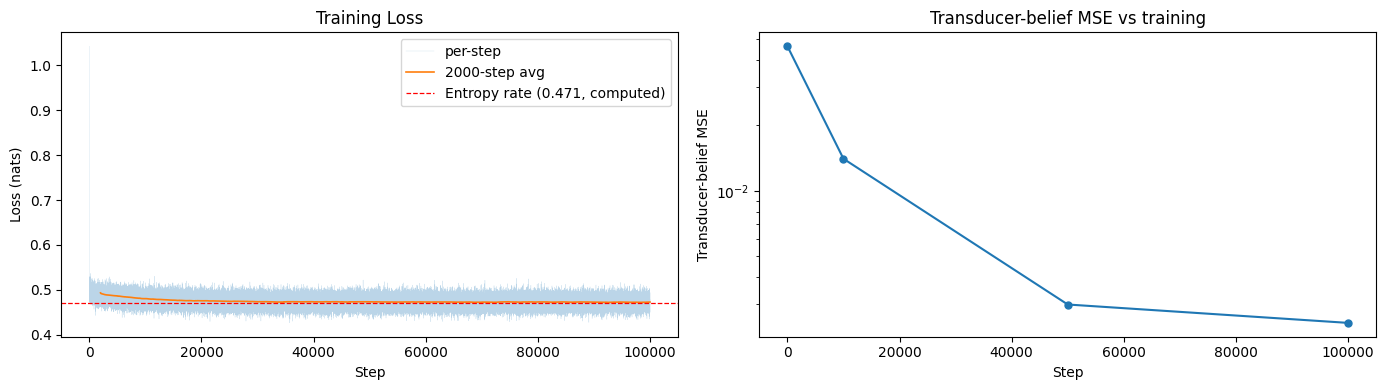


Predictive fit:
  d_mu (mean per-position KL P||Q) = 0.00069 nats   (0 = perfect process model)
  model CE on held-out sequence    = 0.4748 nats
  entropy-rate floor h_mu          = 0.4706 nats
  gap (CE - h_mu)                  = +0.0042 nats


In [9]:
# ---- Training curves vs the computed entropy-rate floor ----
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax = axes[0]
ax.plot(losses, lw=0.2, alpha=0.3, label='per-step')
w = min(2000, len(losses) // 5) if len(losses) > 10 else 1
if w > 1:
    sm = np.convolve(losses, np.ones(w) / w, mode='valid')
    ax.plot(np.arange(w - 1, w - 1 + len(sm)), sm, lw=1.2, label=f'{w}-step avg')
ax.axhline(ENTROPY_RATE, color='red', ls='--', lw=0.9, label=f'Entropy rate ({ENTROPY_RATE:.3f}, computed)')
ax.set_xlabel('Step'); ax.set_ylabel('Loss (nats)'); ax.set_title('Training Loss'); ax.legend()

ax = axes[1]
steps = sorted(checkpoint_results)
mses = [checkpoint_results[s]['paper_mse'] for s in steps]
ax.plot(steps, mses, 'o-', ms=5)
ax.set_xlabel('Step'); ax.set_ylabel('Transducer-belief MSE'); ax.set_yscale('log')
ax.set_title('Transducer-belief MSE vs training')
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/fig_training.png', dpi=150, bbox_inches='tight'); plt.show()

# ---- Predictive-fit metric (aim.md §5b/§9b): closed-form per-position KL d_mu + entropy gap ----
# P_t = analytical next-token dist from the belief (via the active operator);
# Q_t = model softmax. d_mu = mean_t KL(P_t || Q_t) >= 0. Also report <loss> - h_mu.
def predictive_dmu(net, n_seqs=2000, seq_len=N_CTX):
    seqs = generate_sequences(np.random.default_rng(SEED + 555), n_seqs, seq_len)
    beliefs = compute_beliefs(seqs)                         # (n, T, n_joint)
    P = next_token_dist(beliefs)                            # (n, T, VOCAB) analytical
    net.eval()
    seqs_t = torch.tensor(seqs, dtype=torch.long)
    kls, ces = [], []
    with torch.no_grad():
        for s in range(0, n_seqs, 2048):
            logits = net(seqs_t[s:s + 2048].to(DEVICE))
            Q = torch.softmax(logits, dim=-1).cpu().numpy()  # (b, T, VOCAB)
            Pb = P[s:s + 2048]
            kl = np.sum(Pb * (np.log(Pb + 1e-30) - np.log(Q + 1e-30)), axis=-1)
            kls.append(kl.reshape(-1))
            # model cross-entropy of the actual next token (for the entropy-rate gap)
            nxt = seqs[s:s + 2048, 1:]
            q_next = Q[:, :-1, :]
            ce = -np.log(np.take_along_axis(q_next, nxt[:, :, None], axis=-1)[..., 0] + 1e-30)
            ces.append(ce.reshape(-1))
    return float(np.mean(np.concatenate(kls))), float(np.mean(np.concatenate(ces)))

D_MU, MODEL_CE = predictive_dmu(model)
print(f'\nPredictive fit:')
print(f'  d_mu (mean per-position KL P||Q) = {D_MU:.5f} nats   (0 = perfect process model)')
print(f'  model CE on held-out sequence    = {MODEL_CE:.4f} nats')
print(f'  entropy-rate floor h_mu          = {ENTROPY_RATE:.4f} nats')
print(f'  gap (CE - h_mu)                  = {MODEL_CE - ENTROPY_RATE:+.4f} nats')

## 4. Linear probes — fit to the **regime-correct** belief

We fit the residual stream to the belief states of the **active operator** (`OBSERVE`): the
joint belief and its input / transducer marginals. Under `'joint'` these are the separable
product beliefs (both marginals should be cleanly recoverable). Under `'output_only'` the joint
belief is the **entangled cascade** belief — expect the joint to be recoverable while the
marginals **lag** (the driver-lag the mentor flagged); that lag is the *information the
transducer erased*. Per-layer + concatenated, each with an **untrained-model baseline**.

In [10]:
# ---- Analysis data + activations (trained and untrained) ----
print(f'Generating {ANALYSIS_SEQS:,} sequences...')
analysis_seqs = generate_sequences(np.random.default_rng(SEED + 999), ANALYSIS_SEQS, N_CTX)
analysis_beliefs = compute_beliefs(analysis_seqs)               # (S, T, n_joint)

eta_flat = analysis_beliefs.reshape(-1, n_joint)                # joint belief
in_flat, tr_flat = joint_to_marginals(eta_flat)                 # input / transducer marginals
n_data = eta_flat.shape[0]
print(f'data points: {n_data:,}  |  targets: joint({n_joint}D) input({n_R}D) transducer({n_S}D)')

print('Extracting trained activations...')
trained_layers = extract_activations(model, analysis_seqs)
concat_acts = np.concatenate([trained_layers[k] for k in all_layer_keys], axis=1)

print('Extracting untrained-baseline activations...')
untrained_model, _ = make_model(SEED + 12345, ACTUAL_N_HEADS)
untrained_layers = extract_activations(untrained_model, analysis_seqs)
untrained_concat = np.concatenate([untrained_layers[k] for k in all_layer_keys], axis=1)
del untrained_model
if DEVICE == 'cuda':
    torch.cuda.empty_cache()

TARGETS = {'joint': eta_flat, 'input': in_flat, 'transducer': tr_flat}
# input belief is constant when n_R == 1 (IID): probe R^2 is undefined; we flag it.
print('input belief is trivial (constant)' if n_R == 1 else f'input belief has {n_R} components')

Generating 10,000 sequences...
data points: 500,000  |  targets: joint(4D) input(2D) transducer(2D)
Extracting trained activations...
Extracting untrained-baseline activations...
input belief has 2 components


target      layer     trained R2   trained MSE    untrn R2     untrn MSE
------------------------------------------------------------------------------
joint       L0            0.8541      0.035042      0.7973      0.048674
joint       L1            0.8801      0.028795      0.8057      0.046675
joint       L2            0.8938      0.025497      0.8002      0.047976
joint       L3            0.9042      0.022998      0.8002      0.047985
joint       Concat        0.9298      0.016869      0.8475      0.036630

input       L0            0.0214      0.023976      0.0474      0.023340
input       L1            0.0466      0.023360      0.0578      0.023084
input       L2            0.0675      0.022847      0.0591      0.023054
input       L3            0.0855      0.022407      0.0595      0.023043
input       Concat        0.2804      0.017631      0.1247      0.021445

transducer  L0            0.9417      0.023975      0.8928      0.044094
transducer  L1            0.9720      0.011

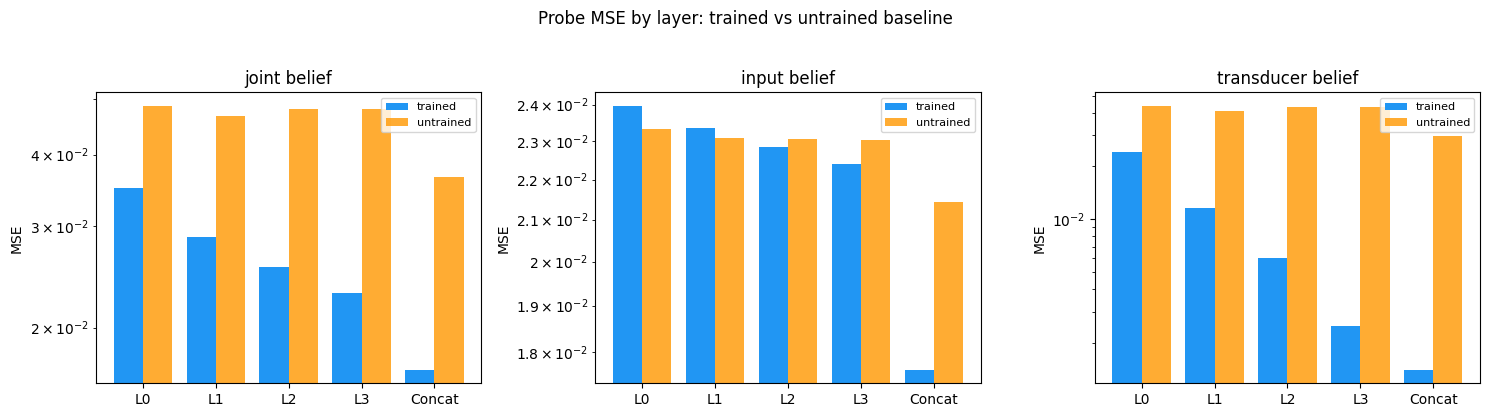

4757

In [11]:
# ---- Run probes: per-layer + concat, trained + untrained baseline ----
layer_labels = [f'L{l}' for l in range(N_LAYERS)] + ['Concat']

def probes_for(acts_by_layer, acts_concat):
    out = {}
    for tname, target in TARGETS.items():
        out[tname] = {}
        for k, lbl in zip(all_layer_keys, layer_labels[:-1]):
            out[tname][lbl] = ols_fit_eval(acts_by_layer[k], target)
        out[tname]['Concat'] = ols_fit_eval(acts_concat, target)
    return out

results = probes_for(trained_layers, concat_acts)
results_untrained = probes_for(untrained_layers, untrained_concat)

print('=' * 78)
print(f'{"target":<12}{"layer":<8}{"trained R2":>12}{"trained MSE":>14}{"untrn R2":>12}{"untrn MSE":>14}')
print('-' * 78)
for tname in TARGETS:
    for lbl in layer_labels:
        tr_r = results[tname][lbl]; un_r = results_untrained[tname][lbl]
        print(f'{tname:<12}{lbl:<8}{tr_r["r2"]:>12.4f}{tr_r["mse"]:>14.6f}{un_r["r2"]:>12.4f}{un_r["mse"]:>14.6f}')
    print()

# ---- Bar chart: trained vs untrained MSE per target (concat) ----
fig, axes = plt.subplots(1, len(TARGETS), figsize=(5 * len(TARGETS), 4))
if len(TARGETS) == 1:
    axes = [axes]
for ax, tname in zip(axes, TARGETS):
    tr_mse = [results[tname][l]['mse'] for l in layer_labels]
    un_mse = [results_untrained[tname][l]['mse'] for l in layer_labels]
    x = np.arange(len(layer_labels)); width = 0.4
    ax.bar(x - width / 2, tr_mse, width, label='trained', color='#2196F3')
    ax.bar(x + width / 2, un_mse, width, label='untrained', color='#FF9800', alpha=0.8)
    ax.set_xticks(x); ax.set_xticklabels(layer_labels); ax.set_yscale('log')
    ax.set_ylabel('MSE'); ax.set_title(f'{tname} belief'); ax.legend(fontsize=8)
plt.suptitle('Probe MSE by layer: trained vs untrained baseline', y=1.03)
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/fig_probes.png', dpi=150, bbox_inches='tight'); plt.show()

# free the untrained-baseline activations (numbers already stored in results_untrained) to save RAM
del untrained_layers, untrained_concat
gc.collect()

## 5. Controls (on the transducer-belief concat probe)

Sequence-level cross-validation (holds out whole sequences -> no within-sequence leakage),
shuffle (destroys the activation<->belief pairing), and temporal split (train on first half of
positions, test on second) to expose position-specific encoding.

Shuffle: 100%|██████████| 50/50 [10:40<00:00, 12.82s/it]



=== Controls (transducer belief, concat) ===
  full_mse               0.001398
  untrained_mse          0.029508
  seq_cv_test_mean       0.001404
  seq_cv_test_std        0.000004
  tsplit_mse             0.075953
  shuffle_mse_mean       0.411210
  shuffle_mse_std        0.000020

  shuffle/full   = 294.1x
  untrained/full = 21.1x
  seq-CV/full    = 1.00x (≈1 means no overfitting)


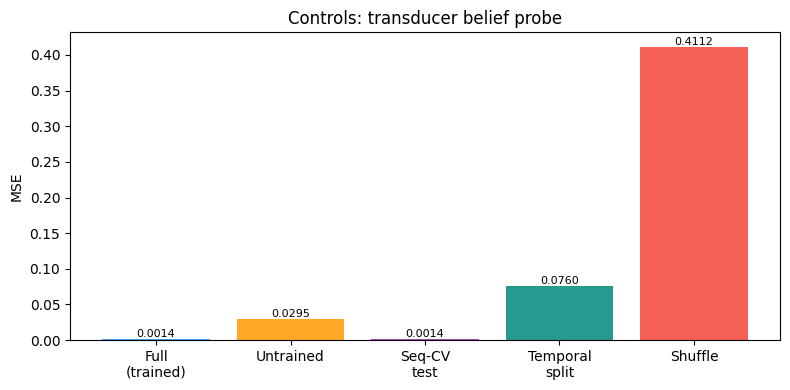

5

In [12]:
# ---- Controls on the transducer belief (concat probe) ----
CTRL_TARGET = tr_flat
N_TRIALS = 50
ctrl_rng = np.random.default_rng(SEED)
full_mse = results['transducer']['Concat']['mse']
untrained_mse = results_untrained['transducer']['Concat']['mse']

def fit_test_mse(tr_i, te_i):
    X_tr = np.column_stack([np.ones(len(tr_i)), concat_acts[tr_i]]).astype(np.float64)
    beta, _, _, _ = np.linalg.lstsq(X_tr, CTRL_TARGET[tr_i].astype(np.float64), rcond=None)
    X_te = np.column_stack([np.ones(len(te_i)), concat_acts[te_i]]).astype(np.float64)
    r = X_te @ beta - CTRL_TARGET[te_i]
    return float(np.mean(np.sum(r ** 2, axis=1)))

# sequence-level CV (20% train / 80% test, whole sequences)
seq_cv = []
for _ in tqdm(range(N_TRIALS), desc='Seq-CV'):
    perm = ctrl_rng.permutation(ANALYSIS_SEQS)
    ntr = int(0.2 * ANALYSIS_SEQS)
    tr_i = np.concatenate([np.arange(s * N_CTX, (s + 1) * N_CTX) for s in perm[:ntr]])
    te_i = np.concatenate([np.arange(s * N_CTX, (s + 1) * N_CTX) for s in perm[ntr:]])
    seq_cv.append(fit_test_mse(tr_i, te_i))

# shuffle
shuffle_mse = []
X_all = np.column_stack([np.ones(n_data), concat_acts]).astype(np.float64)
for _ in tqdm(range(N_TRIALS), desc='Shuffle'):
    p = ctrl_rng.permutation(n_data)
    beta, _, _, _ = np.linalg.lstsq(X_all, CTRL_TARGET[p].astype(np.float64), rcond=None)
    r = X_all @ beta - CTRL_TARGET[p]
    shuffle_mse.append(float(np.mean(np.sum(r ** 2, axis=1))))

# temporal split (first half positions -> second half, and reverse)
mid = N_CTX // 2
first = np.concatenate([np.arange(s * N_CTX, s * N_CTX + mid) for s in range(ANALYSIS_SEQS)])
second = np.concatenate([np.arange(s * N_CTX + mid, (s + 1) * N_CTX) for s in range(ANALYSIS_SEQS)])
tsplit = 0.5 * (fit_test_mse(first, second) + fit_test_mse(second, first))

controls = {
    'full_mse': full_mse, 'untrained_mse': untrained_mse,
    'seq_cv_test_mean': float(np.mean(seq_cv)), 'seq_cv_test_std': float(np.std(seq_cv)),
    'tsplit_mse': float(tsplit),
    'shuffle_mse_mean': float(np.mean(shuffle_mse)), 'shuffle_mse_std': float(np.std(shuffle_mse)),
}
print('\n=== Controls (transducer belief, concat) ===')
for k, v in controls.items():
    print(f'  {k:<22} {v:.6f}')
print(f'\n  shuffle/full   = {np.mean(shuffle_mse)/max(full_mse,1e-12):.1f}x')
print(f'  untrained/full = {untrained_mse/max(full_mse,1e-12):.1f}x')
print(f'  seq-CV/full    = {np.mean(seq_cv)/max(full_mse,1e-12):.2f}x (≈1 means no overfitting)')

fig, ax = plt.subplots(figsize=(8, 4))
lab = ['Full\n(trained)', 'Untrained', 'Seq-CV\ntest', 'Temporal\nsplit', 'Shuffle']
val = [full_mse, untrained_mse, np.mean(seq_cv), tsplit, np.mean(shuffle_mse)]
ax.bar(lab, val, color=['#2196F3', '#FF9800', '#9C27B0', '#00897B', '#F44336'], alpha=0.85)
ax.set_ylabel('MSE'); ax.set_title('Controls: transducer belief probe')
for i, v in enumerate(val):
    ax.text(i, v, f'{v:.4f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/fig_controls.png', dpi=150, bbox_inches='tight'); plt.show()

del X_all
gc.collect()

## 6. Ground-truth MSP vs learned geometry

Two views: (left column) the **joint belief manifold** on the `(input-marginal, transducer-
marginal)` plane — ground truth vs the residual-stream readout — which reproduces the explorer's
product (separable) vs cascade (entangled) picture; (right) the transducer-belief predicted-vs-
true check with the countable-MSP rug.

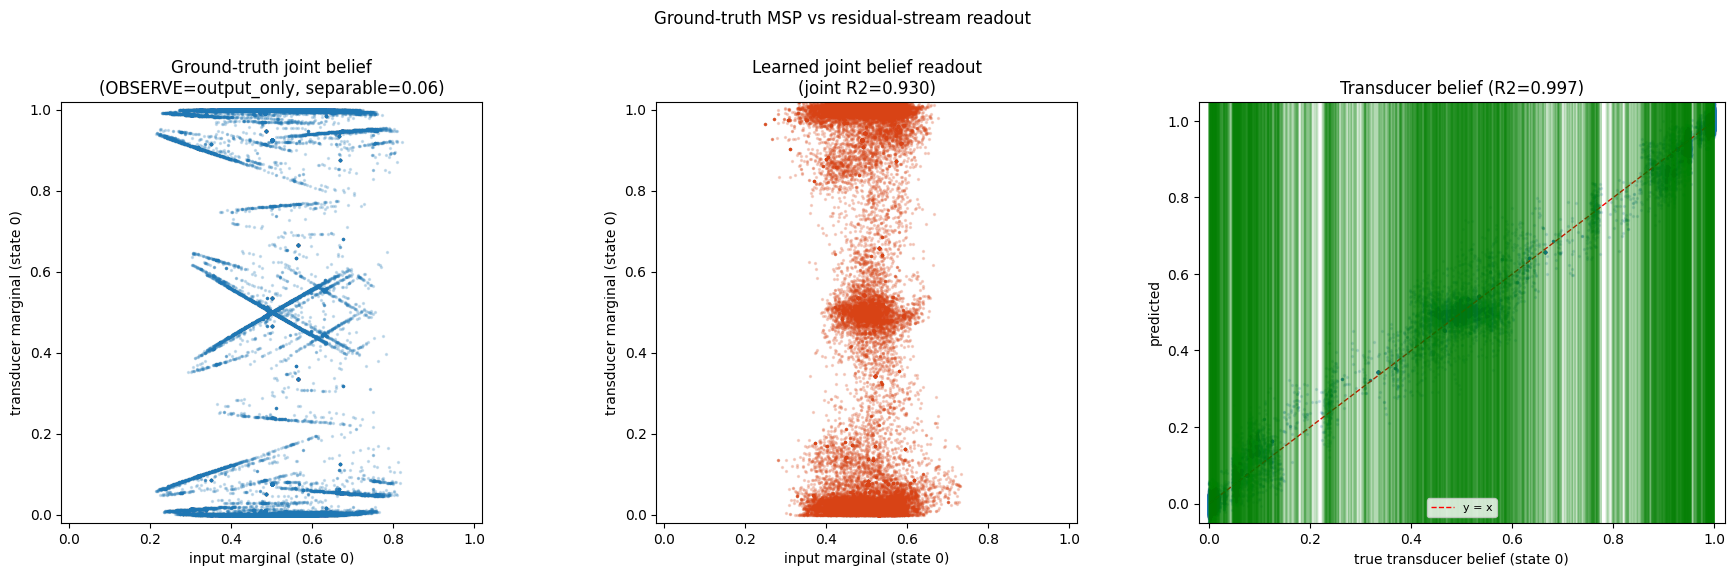

In [13]:
# ---- Learned geometry from the concat probes ----
X_c = np.column_stack([np.ones(n_data), concat_acts]).astype(np.float64)
beta_joint, _, _, _ = np.linalg.lstsq(X_c, eta_flat.astype(np.float64), rcond=None)
pred_joint = (X_c @ beta_joint).astype(np.float32)
beta_tr, _, _, _ = np.linalg.lstsq(X_c, tr_flat.astype(np.float64), rcond=None)
pred_tr = (X_c @ beta_tr).astype(np.float32)

n_plot = min(40_000, n_data)
idx = np.random.default_rng(0).choice(n_data, n_plot, replace=False)
in_true, tr_true = joint_to_marginals(eta_flat[idx])
in_pred, tr_pred = joint_to_marginals(np.clip(pred_joint[idx], 0, None))

fig, axes = plt.subplots(1, 3, figsize=(18, 5.6))

# (1) joint belief manifold: ground truth (product vs entangled)
axes[0].scatter(in_true[:, 0], tr_true[:, 0], s=2, alpha=0.2, rasterized=True)
axes[0].set_title(f'Ground-truth joint belief\n(OBSERVE={OBSERVE}, separable={SEPARABILITY[OBSERVE]:.2f})')
axes[0].set_xlabel('input marginal (state 0)'); axes[0].set_ylabel('transducer marginal (state 0)')
axes[0].set_xlim(-0.02, 1.02); axes[0].set_ylim(-0.02, 1.02); axes[0].set_aspect('equal')

# (2) joint belief manifold: residual-stream readout
axes[1].scatter(in_pred[:, 0], tr_pred[:, 0], s=2, alpha=0.2, color='#D84315', rasterized=True)
axes[1].set_title(f"Learned joint belief readout\n(joint R2={results['joint']['Concat']['r2']:.3f})")
axes[1].set_xlabel('input marginal (state 0)'); axes[1].set_ylabel('transducer marginal (state 0)')
axes[1].set_xlim(-0.02, 1.02); axes[1].set_ylim(-0.02, 1.02); axes[1].set_aspect('equal')

# (3) transducer belief predicted-vs-true with countable-MSP rug (2-state) or simplex embed
ax = axes[2]
if n_S == 2:
    ax.scatter(tr_flat[idx, 0], pred_tr[idx, 0], s=2, alpha=0.15, rasterized=True)
    ax.plot([0, 1], [0, 1], 'r--', lw=1, label='y = x')
    for v in np.unique(msp_trans[:, 0].round(4)):
        ax.axvline(v, color='green', lw=0.3, alpha=0.4)
    ax.set_xlabel('true transducer belief (state 0)'); ax.set_ylabel('predicted')
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.05, 1.05); ax.legend(fontsize=8)
else:
    et, ep = embed_simplex(tr_flat[idx]), embed_simplex(np.clip(pred_tr[idx], 0, None))
    ax.scatter(et[:, 0], et[:, 1], s=2, alpha=0.2, label='true', rasterized=True)
    ax.scatter(ep[:, 0], ep[:, 1], s=2, alpha=0.2, color='#D84315', label='pred', rasterized=True)
    ax.legend(fontsize=8); ax.set_aspect('equal')
ax.set_title(f"Transducer belief (R2={results['transducer']['Concat']['r2']:.3f})")

plt.suptitle('Ground-truth MSP vs residual-stream readout', y=1.02)
plt.tight_layout(); plt.savefig(f'{FIG_DIR}/fig_msp_vs_learned.png', dpi=150, bbox_inches='tight'); plt.show()

## 7. Save checkpoint

In [14]:
save_dir = CKPT_NAME
os.makedirs(save_dir, exist_ok=True)

wpath = f'{save_dir}/model_weights.pt'
if not os.path.exists(wpath):
    torch.save(model.state_dict(), wpath)

def _j(v):
    """Sanitize NaN (e.g. trivial IID input R^2) to null for strict-JSON validity."""
    return None if (isinstance(v, float) and np.isnan(v)) else v

config_dict = {
    'observe': OBSERVE,
    'input_mode': INPUT_MODE, 'transducer_mode': TRANSDUCER_MODE,
    'iid_p1': IID_P1, 'sns_tr_p0': SNS_TR_P0, 'sns_tr_p1': SNS_TR_P1,
    'n_y': n_y, 'n_x': n_x, 'n_R': n_R, 'n_S': n_S, 'vocab': VOCAB_SIZE,
    'n_ctx': N_CTX, 'd_model': D_MODEL, 'n_layers': N_LAYERS, 'n_heads': ACTUAL_N_HEADS,
    'd_mlp': D_MLP, 'seed': SEED, 'num_steps_trained': NUM_STEPS,
    'entropy_rate': float(ENTROPY_RATE),
    'final_loss_smoothed': float(np.mean(losses[-10000:])),
    'd_mu': float(D_MU), 'model_ce': float(MODEL_CE),
    'separability': {k: _j(v) for k, v in SEPARABILITY.items()},
    'transducer_r2_concat': _j(results['transducer']['Concat']['r2']),
    'transducer_mse_concat': _j(results['transducer']['Concat']['mse']),
    'joint_r2_concat': _j(results['joint']['Concat']['r2']),
    'input_r2_concat': _j(results['input']['Concat']['r2']),
}
with open(f'{save_dir}/config.json', 'w') as f:
    json.dump(config_dict, f, indent=2)

np.savez_compressed(f'{save_dir}/training_history.npz',
    losses=np.array(losses),
    checkpoint_steps=np.array(sorted(checkpoint_results)),
    checkpoint_mses=np.array([checkpoint_results[s]['paper_mse'] for s in sorted(checkpoint_results)]),
    checkpoint_r2s=np.array([checkpoint_results[s]['r2'] for s in sorted(checkpoint_results)]))

probe_data = {}
for tname in results:
    for lbl in results[tname]:
        probe_data[f'{tname}_{lbl}_r2'] = results[tname][lbl]['r2']
        probe_data[f'{tname}_{lbl}_mse'] = results[tname][lbl]['mse']
        probe_data[f'untrained_{tname}_{lbl}_r2'] = results_untrained[tname][lbl]['r2']
        probe_data[f'untrained_{tname}_{lbl}_mse'] = results_untrained[tname][lbl]['mse']
np.savez_compressed(f'{save_dir}/probe_results.npz', **probe_data)

with open(f'{save_dir}/controls.json', 'w') as f:
    json.dump(controls, f, indent=2)

zip_name = f'{CKPT_NAME}.zip'
with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
    for root, _, fns in os.walk(save_dir):
        for fn in fns:
            zf.write(os.path.join(root, fn))
print(f'Saved {zip_name}')

# ---- persist to Google Drive so it survives session recycling ----
if SAVE_TO_DRIVE:
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        os.makedirs(DRIVE_DIR, exist_ok=True)
        import shutil
        shutil.copy(zip_name, f'{DRIVE_DIR}/{zip_name}')
        print(f'Copied to Google Drive: {DRIVE_DIR}/{zip_name}')
    except Exception as e:
        print(f'Drive save skipped ({e}); zip is at /content/{zip_name}')
else:
    try:
        from google.colab import files
        files.download(zip_name)
    except ImportError:
        print('Not in Colab -- zip saved locally.')

Mounted at /content/drive
Copied to Google Drive: /content/drive/MyDrive/transducer_runs/transducer_ckpt_fractal2_fractal2_output_only.zip


## 8. Erasure cross-fit (run in the `output_only` regime, against the live model)

Quantifies **how much information the transducer erased** by hiding the intermediate token.
We sample the full `(y, x)` process, feed the x-only model **only `x`**, and fit its residual
stream to two targets: (a) the **x-only `W`-belief** it was trained to track, and (b) the
**fully-observable `V`-belief** (what an observer of both `y` and `x` would hold). The **R² drop
from (a) to (b) — especially on the input marginal — is the erased information.**

In [18]:
# ---- Erasure cross-fit: fit the x-only model's residual stream to the FULL (separable) belief ----
assert OBSERVE == 'output_only', "Run this in the output_only regime (the coarse-grained model)."
n_cf = ANALYSIS_SEQS
rng_cf = np.random.default_rng(SEED + 4242)

# 1) sample the FULL joint (y,x) process from V_joint  (token k = y*n_x + x)
statesJ = np.tile(stationary, (n_cf, 1))
yx = np.zeros((n_cf, N_CTX), dtype=np.int64)
for t in range(N_CTX):
    obs = np.einsum('bi,kij->bk', statesJ, V_joint); obs = np.maximum(obs, 0); obs /= obs.sum(1, keepdims=True)
    cum = obs.cumsum(1); u = rng_cf.random(n_cf)[:, None]
    k = np.clip((u >= cum).sum(1), 0, V_joint.shape[0] - 1); yx[:, t] = k
    statesJ = np.einsum('bi,bij->bj', statesJ, V_joint[k]); statesJ /= statesJ.sum(1, keepdims=True)
x_seq = (yx % n_x).astype(np.int64)   # exactly what the x-only model observes

# 2) beliefs along the SAME sequence: W (x-only, trained target) vs V (full, separable)
def _beliefs_via(op, tokens):
    sT = np.tile(stationary, (tokens.shape[0], 1))
    B = np.zeros((tokens.shape[0], N_CTX, n_joint), np.float32)
    for t in range(N_CTX):
        sT = np.einsum('bi,bij->bj', sT, op[tokens[:, t]]); sT /= sT.sum(1, keepdims=True); B[:, t] = sT
    return B
Win, Wtr = joint_to_marginals(_beliefs_via(W_cg,   x_seq).reshape(-1, n_joint))   # x-only belief
Vin, Vtr = joint_to_marginals(_beliefs_via(V_joint, yx  ).reshape(-1, n_joint))   # full belief

# 3) x-only model activations on x_seq, then fit to each target
concat_cf = np.concatenate([extract_activations(model, x_seq)[k] for k in all_layer_keys], axis=1)
def _r2(a, y): return ols_fit_eval(a, y)['r2']
w_in, w_tr = _r2(concat_cf, Win), _r2(concat_cf, Wtr)
v_in, v_tr = _r2(concat_cf, Vin), _r2(concat_cf, Vtr)

print("=== Erasure cross-fit (x-only model, concat probe) ===")
print(f"  recover x-only W-belief : input R2={w_in:.4f}   transducer R2={w_tr:.4f}")
print(f"  recover FULL  V-belief  : input R2={v_in:.4f}   transducer R2={v_tr:.4f}")
# ROBUST erasure metric = 1 - (x-only model's recovery of the FULL belief). Low full-R2 = erased.
# (The W-V gap is only meaningful when the x-only W-belief is itself high-variance; report both.)
print(f"  ERASURE (1 - full-belief R2): input ~{100*(1-v_in):.0f}% erased   "
        f"transducer ~{100*(1-v_tr):.0f}% erased")
print(f"  [full-belief recoverable R2: input {v_in:.3f}, transducer {v_tr:.3f}; "
        f"separability={SEPARABILITY['output_only']:.3f}]")
print(f"  [context: x-only W-belief R2 input {w_in:.3f}, transducer {w_tr:.3f}; "
        f"W-V gap input {w_in - v_in:+.3f}]")
del concat_cf, yx, x_seq
gc.collect()

=== Erasure cross-fit (x-only model, concat probe) ===
  recover x-only W-belief : input R2=0.2776   transducer R2=0.9966
  recover FULL  V-belief  : input R2=0.0168   transducer R2=0.9227
  ERASURE (1 - full-belief R2): input ~98% erased   transducer ~8% erased
  [full-belief recoverable R2: input 0.017, transducer 0.923; separability=0.059]
  [context: x-only W-belief R2 input 0.278, transducer 0.997; W-V gap input +0.261]


0